CODE FOR ASSESSMENT 2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

QUESTION 1

a. Calculate beta parameters in linear regressions and the correlations for all datasets. Hint: Do you need to calculate the beta parameters and correlations for each one separately?

b. Make plots for all of them (don’t use already existing plots) along with trend lines. Remember the “Subset by” functionality – exists only on Inzight to help make the scatterplot matrix.

c. Given the correlations are so low, does that mean there is no relationship between variables for this dataset? What is an alternative technique that would help us to model relationships between variables here?

In [2]:
dino = pd.read_csv("datasaurus.csv")
dino.head()   

,dataset,x,y
0,dino,55.3846,97.1795
1,dino,51.5385,96.0256
2,dino,46.1538,94.4872
3,dino,42.8205,91.4103
4,dino,40.7692,88.3333


In [3]:
print(dino["dataset"].unique())

['dino' 'away' 'h_lines' 'v_lines' 'x_shape' 'star' 'high_lines' 'dots'
 'circle' 'bullseye' 'slant_up' 'slant_down' 'wide_lines']


In [4]:
#create a dictionary of invidual data frames (one for each dataset)
split = {name: group for name, group in dino.groupby('dataset')}

In [5]:
#calculations for mean and standard deviations of values of meanY, meanX, covariance, varX, stdY, stdX across datasets

df = pd.DataFrame(columns=["meanY", "meanX", "covariance", 'varX', "stdY", "stdX"])
for ds in split: 
    df.loc[len(df),["meanY"]] = split[ds]["y"].mean()
    df.loc[len(df),["meanX"]] = split[ds]["x"].mean()
    df.loc[len(df),["covariance"]] = split[ds]["x"].cov(split[ds]["y"])
    df.loc[len(df),["varX"]] = split[ds]["x"].var()
    df.loc[len(df),["stdY"]] = split[ds]["y"].std()
    df.loc[len(df),["stdX"]] = split[ds]["x"].std()

print(f"meanY mean + std: {df["meanY"].mean()}, {df["meanY"].std()}\nmeanX mean + std: {df["meanX"].mean()}, {df["meanX"].std()}\ncovariance mean + std: {df["covariance"].mean()}, {df["covariance"].std()}\nvarX mean + std: {df["varX"].mean()}, {df["varX"].std()}\nstdY mean + std: {df["stdY"].mean()}, {df["stdY"].std()}\nstdX mean + std: {df["stdX"].mean()}, {df["stdX"].std()}")

#approximated line for all datasets
print(f"\nRegression line: y = {round(df["meanY"].mean(),2)} + {round((df["covariance"].mean()/df["varX"].mean()),4)}(x-{round(df["meanX"].mean(),2)})")

#approximated correlation for all datasets
corr = (df["covariance"].mean()/(df["stdX"].mean()*df["stdY"].mean()))
print(f"\nCorrelation: corr = {corr}")

meanY mean + std: 47.83509920412269, 0.0035342279267824477
meanX mean + std: 54.265695295881045, 0.0033196695866574057
covariance mean + std: -29.817061993263785, 1.3805315270200769
varX mean + std: 281.1530448038597, 0.09482297154699529
stdY mean + std: 26.935503884209673, 0.004016466481237866
stdX mean + std: 16.767618716499655, 0.0028279166493519604

Regression line: y = 47.84 + -0.1061(x-54.27)

Correlation: corr = -0.06601891066842007


given the regression line y = b0 + b1(x-meanX):

The mean values for each dataset vary only by ~ 0.0035. Thus, b0 intercept in the regression line equations for each dataset will be approximately the same.
Moreover given the formula for b1 = Σ(xi - meanX)(yi - meanY) / Σ(xi - meanX)² we can directly relate this to covariance and variance. When we divide both numerator and denominator by n we get b1=cov(xy)/var(x). For our datasets we see that the variance of x varies only by 0.09 across datasets. Thus the denominator for b1 is aproximatelly the same across datasets. For the numerator, thus the covariance, the values vary by 1.38 across datasets. Consequently, the numerator for b1 will differ across datasets, the values are expected to vary between -31.3 and -28,5. In conclusion, the regression line for each of the dataset will vary, but not greatly, thus we can approximate it for all by calculating the regression line by taking the means calculated above.

Below are correlation plots for all the datasets along with calculated correlation and regression line for each.

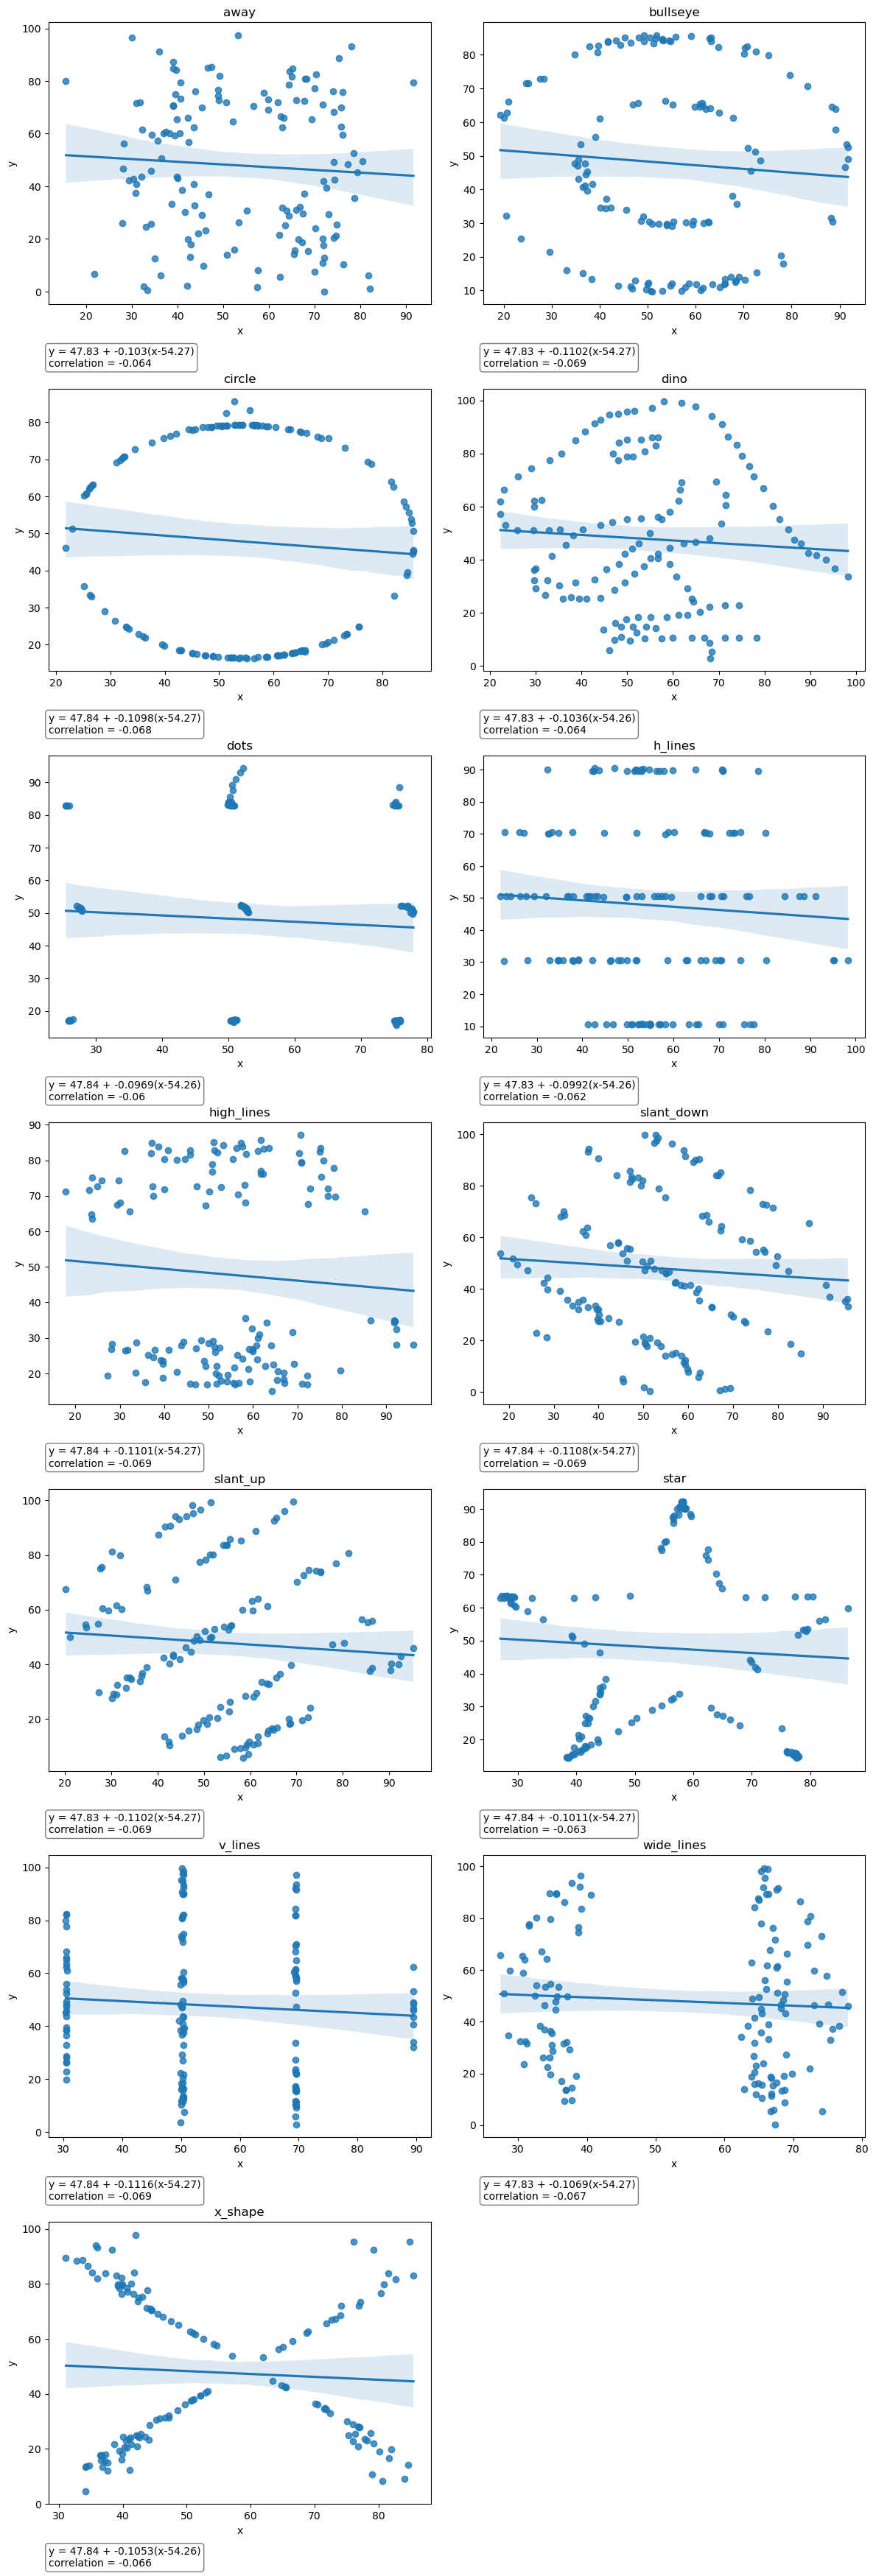

In [6]:
#plotting each dataset with it's regression line and correlation displayed

import math

datasets = list(split.keys())
n = len(datasets)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
axes = axes.flatten()

for i, ds in enumerate(datasets):
    corr = split[ds]["x"].corr(split[ds]["y"])
    meanX = split[ds]["x"].mean()
    meanY = split[ds]["y"].mean()
    b0 = meanY
    num = 0
    den = 0
    for row in split[ds].itertuples(index=False, name="Tuple"):
        num += (row.y - meanY) * (row.x - meanX)
        den += (row.x - meanX) * (row.x - meanX)
    b1 = num / den

    sns.regplot(data=split[ds], x="x", y="y", ax=axes[i])
    axes[i].text(0, -0.15, f"y = {round(b0,2)} + {round(b1,4)}(x-{round(meanX,2)})\ncorrelation = {round(corr,3)}",
        transform=axes[i].transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
    axes[i].set_title(ds)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("q1.png", dpi=150, bbox_inches="tight")
plt.show()

QUESTION 3

Get bootstrapped confidence intervals for the average (is the mean or median a
better average to use?) homicide rate (only that one variable) across the states of
the USA using the dataset you worked with from Assessment 1. Make a figure and
report the 90% confidence intervals. Compare bootstrapped confidence intervals to
the confidence interval when assuming the central limit theorem holds.

In [7]:
us_guns = pd.read_csv("USGunDeaths.csv")

us_guns["Homicide rate"].dropna()
us_guns["Homicide rate"].mean()

np.float64(7.846153846153846)

In [8]:
us_guns.head()

,State,Gun suicide rate,Suicide rate,Gun homicide rate,Homicide rate,% gun at home
0,United States,7.9,14.5,6.3,7.8,[a]
1,Wyoming,23.7,33.0,1.7,2.8,61%
2,Montana,21.6,31.7,2.7,4.2,65%
3,Alaska,19.4,30.0,4.2,6.7,57%
4,New Mexico,14.4,25.0,10.9,14.5,36%


In [9]:
us_guns = us_guns.drop(index=0)
print(us_guns["State"])

1                  Wyoming
2                  Montana
3                   Alaska
4               New Mexico
5                 Oklahoma
6                    Idaho
7             North Dakota
8                   Nevada
9                 Arkansas
10                Colorado
11           West Virginia
12                 Alabama
13                Missouri
14                 Arizona
15                  Oregon
16                Kentucky
17                  Kansas
18               Tennessee
19                   Maine
20                 Vermont
21             Mississippi
22            South Dakota
23                    Utah
24          South Carolina
25                 Georgia
26                 Indiana
27               Louisiana
28                    Iowa
29                 Florida
30          North Carolina
31                   Texas
32                    Ohio
33               Wisconsin
34                Virginia
35                Michigan
36           New Hampshire
37              Washington
3

In [10]:
us_guns.head()

,State,Gun suicide rate,Suicide rate,Gun homicide rate,Homicide rate,% gun at home
1,Wyoming,23.7,33.0,1.7,2.8,61%
2,Montana,21.6,31.7,2.7,4.2,65%
3,Alaska,19.4,30.0,4.2,6.7,57%
4,New Mexico,14.4,25.0,10.9,14.5,36%
5,Oklahoma,13.8,22.0,6.4,8.6,55%


In [11]:
import random

numStates = len(us_guns["Homicide rate"])
bootstrap = pd.DataFrame(columns=["sample", "median", "mean"])

for i in range(1,1001): #1000 bootstrap samples
    samples = []
    for j in range(1, numStates): #one sample the same size as the original dataset
        row = random.randint(1, numStates-1)
        samples.append(us_guns.loc[row, "Homicide rate"])
    median = pd.Series(samples).median()
    mean = pd.Series(samples).mean()
    bootstrap.loc[len(bootstrap)] = [i,median,mean]

bootstrap.head()

,sample,median,mean
0,1.0,6.55,6.850
1,2.0,6.20,6.358
2,3.0,4.80,6.710
3,4.0,7.70,8.362
4,5.0,4.90,7.356


<function matplotlib.pyplot.show(close=None, block=None)>

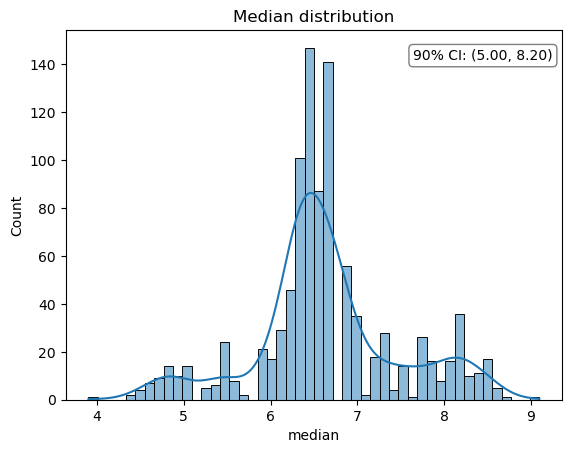

In [14]:
#plotting the boostrap distribution for median and calculating the confidence interval

lower = bootstrap["median"].quantile(0.05)
upper = bootstrap["median"].quantile(0.95)

sns.histplot(bootstrap["median"], kde=True)
plt.text(0.7, 0.95, f"90% CI: ({lower:.2f}, {upper:.2f})",
        transform=plt.gca().transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
plt.title("Median distribution")
plt.savefig("medianboostrap.png", dpi=150, bbox_inches="tight")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

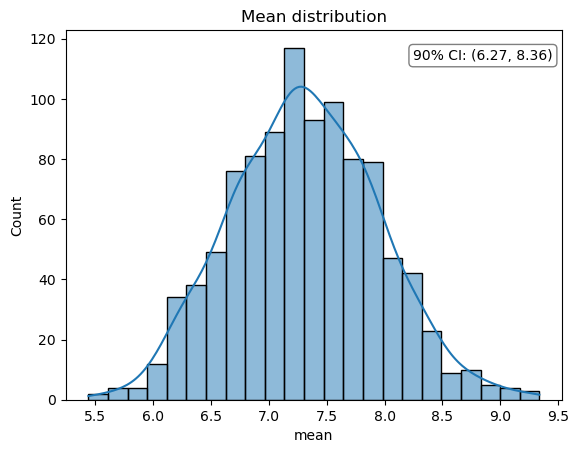

In [15]:
#plotting the boostrap distribution for mean and calculating the confidence interval

lower = bootstrap["mean"].quantile(0.05)
upper = bootstrap["mean"].quantile(0.95)

sns.histplot(bootstrap["mean"], kde=True)
plt.text(0.7, 0.95, f"90% CI: ({lower:.2f}, {upper:.2f})",
        transform=plt.gca().transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
plt.title("Mean distribution")
plt.savefig("meanboostrap.png", dpi=150, bbox_inches="tight")
plt.show

In [16]:
lBMean = bootstrap["mean"].quantile(0.05)
uBMean = bootstrap["mean"].quantile(0.95)

#calculating the CI by CLT
n = len(us_guns["Homicide rate"])
mean = us_guns["Homicide rate"].mean()
se = us_guns["Homicide rate"].std() / np.sqrt(n)

lMean = mean - 1.645 * se  # 1.645 for 90% CI
uMean = mean + 1.645 * se

print(f"sample mean: {round(mean,2)}\nsample std: {round(us_guns["Homicide rate"].std(),2)}\nnum of samples: {n}")
print(f"\nMean 90% CI:\nBootstrap: {lBMean:.2f}, {uBMean:.2f}\nCLT: {lMean:.2f}, {uMean:.2f}")

sample mean: 7.85
sample std: 5.79
num of samples: 51

Mean 90% CI:
Bootstrap: 6.27, 8.36
CLT: 6.51, 9.18


QUESTION 4

Demonstrate the central limit theorem for the mean of a dataset where the data itself is clearly not drawn from a bell curve (remember: non-natural datasets tend to not be Gaussian). Demonstrate first using an appropriate visualization that the data itself is visually not well fit by a bell curve/Gaussian distribution (you don’t need to actually fit a distribution).

In [17]:
gdp = pd.read_csv("gdp_data.csv",encoding="latin1")

gdp["GDP_2025_Billions_USD"] = pd.to_numeric(gdp["GDP_2025_Billions_USD"], errors="coerce")
gdp["GDP_2025_Billions_USD"].dtype

dtype('float64')

In [18]:
gdp.head()

,Country,GDP_2025_Billions_USD
0,Afghanistan,NaN
1,Albania,29939.0
2,Andorra,288015.0
3,Angola,4408.0
4,Antigua and Barbuda,111567.0


In [23]:
print(gdp["Country"])

0              Afghanistan
1                  Albania
2                  Andorra
3                   Angola
4      Antigua and Barbuda
              ...         
190                Vietnam
191     West Bank and Gaza
192                  Yemen
193                 Zambia
194               Zimbabwe
Name: Country, Length: 195, dtype: object


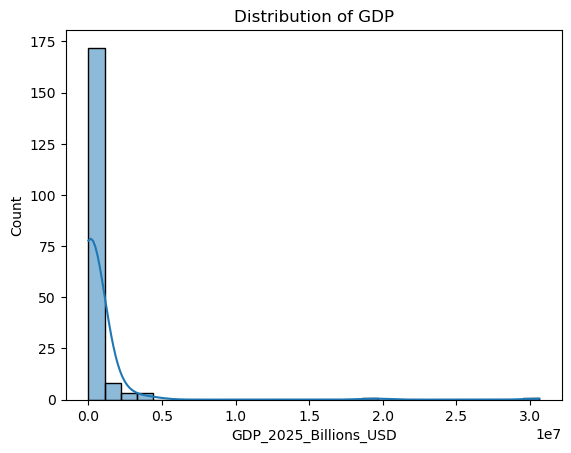

In [19]:
#plotting the distribution 
sns.histplot(gdp["GDP_2025_Billions_USD"].dropna(), kde=True)
plt.title("Distribution of GDP")
plt.savefig("gqpdistribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
#calculation the 90% CI by CLT
n = len(gdp["GDP_2025_Billions_USD"].dropna())
mean = gdp["GDP_2025_Billions_USD"].dropna().mean()
se = gdp["GDP_2025_Billions_USD"].dropna().std() / np.sqrt(n)

low = mean - 1.645 * se  # 1.645 for 90% CI
up = mean + 1.645 * se

print(f"n: {n}\nmean: {round(mean,2)}\nstd: {round(gdp["GDP_2025_Billions_USD"].dropna().std(),2)}")

print(f"\nMean of GDP (country) 90% CI:\n{low:.2f}, {up:.2f}")

n: 188
mean: 566638.93
std: 2690271.86

Mean of GDP (country) 90% CI:
243876.37, 889401.48


In [16]:
#bootrapping from the sample and calculation mean for each bootstrapped sample

import random

numValidStates = len(gdp["GDP_2025_Billions_USD"].dropna())
bootstrap = pd.DataFrame(columns=["sample", "mean"])

for i in range(1,1001): #1000 bootstrap samples
    samples = []
    for j in range(0, numValidStates): #one sample the same size as the original dataset
        row = random.randint(0, numStates-1)
        samples.append(gdp.loc[row, "GDP_2025_Billions_USD"])
    mean = pd.Series(samples).mean()
    bootstrap.loc[len(bootstrap)] = [i,mean]

bootstrap.head()

,sample,mean
0,1.0,1.268185e+06
1,2.0,6.039444e+05
2,3.0,5.008672e+05
3,4.0,7.383622e+05
4,5.0,4.303888e+05


<function matplotlib.pyplot.show(close=None, block=None)>

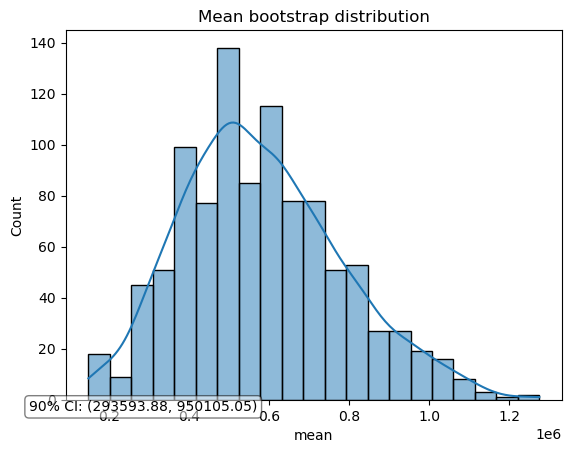

In [24]:
#displaying the bootstrapped distribution and calculating the confidence interval from the distribution
lower = bootstrap["mean"].quantile(0.05)
upper = bootstrap["mean"].quantile(0.95)

sns.histplot(bootstrap["mean"], kde=True)
plt.text(-0.05, -0.05,f"90% CI: ({lower:.2f}, {upper:.2f})",
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
plt.title("Mean bootstrap distribution")
plt.savefig("gdpboot.png", dpi=150, bbox_inches="tight")
plt.show



QUESTION 8

For the following variables from the NHANES dataset, make a plot and explain in 1 line what probability distribution may be appropriate to use for it:

a. Age

b. Marital Status

c. Height of people older than 19

d. Number of babies

In [18]:
nhanes = pd.read_csv("NHANES.csv")
print(nhanes.columns)

Index(['SurveyYr', 'ID', 'Gender', 'Age', 'AgeDecade', 'AgeMonths', 'Race1',
       'Race3', 'Education', 'MaritalStatus', 'HHIncome', 'HHIncomeMid',
       'Poverty', 'HomeRooms', 'HomeOwn', 'Work', 'Weight', 'Length',
       'HeadCirc', 'Height', 'BMI', 'BMICatUnder20yrs', 'BMI_WHO', 'Pulse',
       'BPSysAve', 'BPDiaAve', 'BPSys1', 'BPDia1', 'BPSys2', 'BPDia2',
       'BPSys3', 'BPDia3', 'Testosterone', 'DirectChol', 'TotChol',
       'UrineVol1', 'UrineFlow1', 'UrineVol2', 'UrineFlow2', 'Diabetes',
       'DiabetesAge', 'HealthGen', 'DaysPhysHlthBad', 'DaysMentHlthBad',
       'LittleInterest', 'Depressed', 'nPregnancies', 'nBabies', 'Age1stBaby',
       'SleepHrsNight', 'SleepTrouble', 'PhysActive', 'PhysActiveDays',
       'TVHrsDay', 'ComputerHrsDay', 'TVHrsDayChild', 'CompHrsDayChild',
       'Alcohol12PlusYr', 'AlcoholDay', 'AlcoholYear', 'SmokeNow', 'Smoke100',
       'SmokeAge', 'Marijuana', 'AgeFirstMarij', 'RegularMarij', 'AgeRegMarij',
       'HardDrugs', 'SexEver', 'SexA

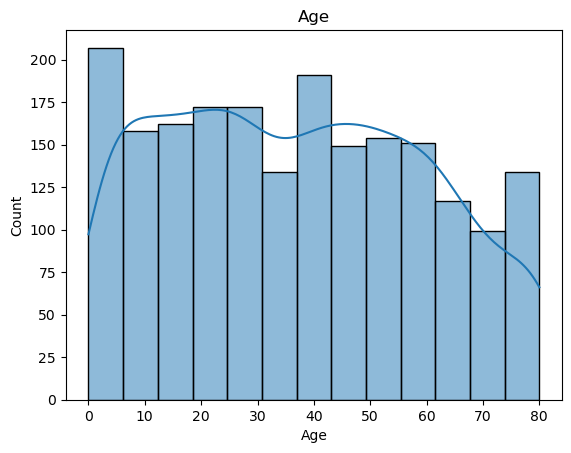

In [19]:
#distribution of age

sns.histplot(nhanes["Age"].dropna(),kde = True)
plt.title("Age")
plt.savefig("age.png", dpi=150, bbox_inches="tight")
plt.show()

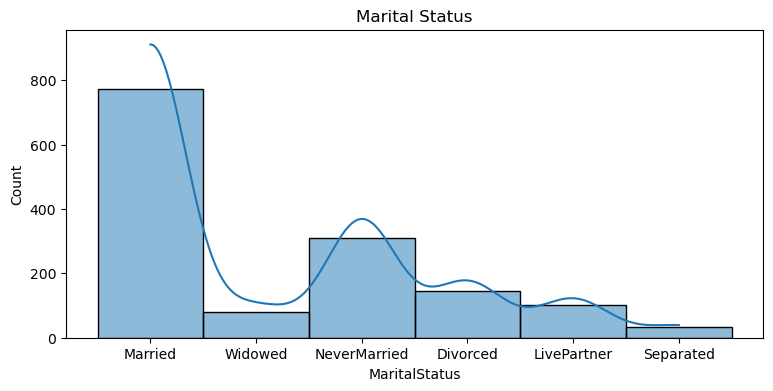

In [20]:
#distribution of marital status

plt.figure(figsize=(1.5*len(nhanes["MaritalStatus"].dropna().unique()), 4))
sns.histplot(nhanes["MaritalStatus"].dropna(),kde = True)
plt.title("Marital Status")
plt.savefig("maritalStatus.png", dpi=150, bbox_inches="tight")
plt.show()

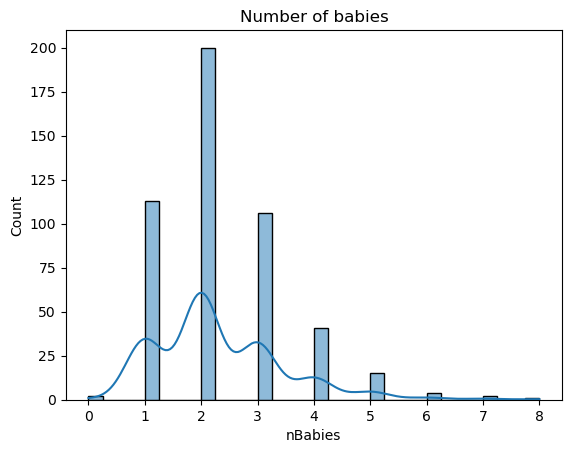

In [21]:
#distribution of number of babies

sns.histplot(nhanes["nBabies"].dropna(), kde = True)
plt.title("Number of babies")
plt.savefig("nBabies.png", dpi=150, bbox_inches="tight")
plt.show()

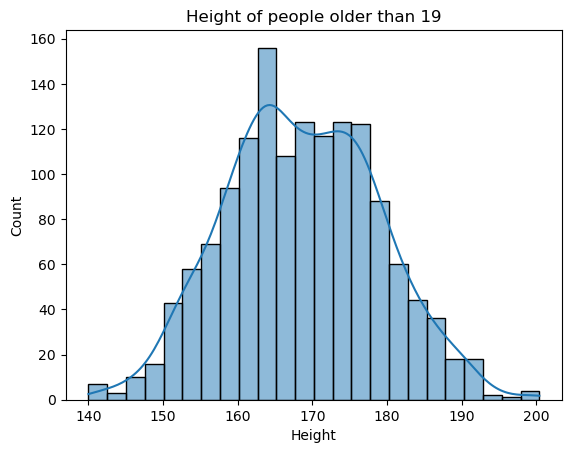

In [22]:
#distribution of height of people older than 19

nhanes["Age"].dropna()
nhanes["Height"].dropna()

sns.histplot(nhanes[nhanes["Age"] > 19]["Height"], kde = True)
plt.title("Height of people older than 19")
plt.savefig("height.png", dpi=150, bbox_inches="tight")
plt.show()